#Preprocessing
Features(V1 to V28) in the dataset are PCA transformed and already standardized. 
Therefore only Time and Amount require preprocessing.

In [30]:
X_train,X_test,y_train,y_test= train_test_split(data.drop(columns=['Class']),data['Class'],test_size=0.2,stratify=data['Class'],random_state=42)

In [31]:
X_train.shape

(226980, 30)

In [32]:
X_test.shape

(56746, 30)

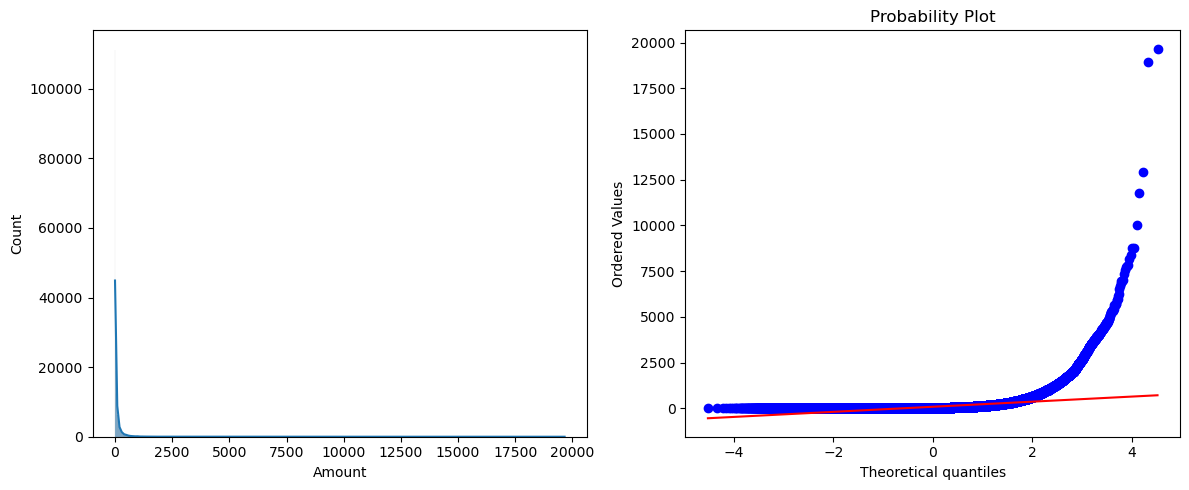

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(X_train["Amount"],kde=True)

plt.subplot(1,2,2)
stats.probplot(X_train["Amount"],dist='norm',plot=plt)
plt.tight_layout()

C:\Users\pragy\AppData\Local\Temp\ipykernel_32936\1675597916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Time"])


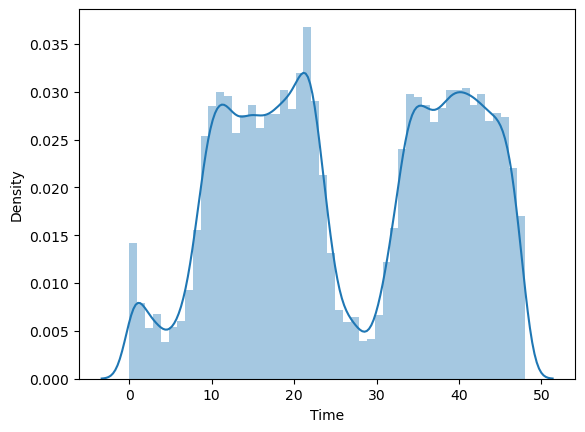

((array([-4.52263148, -4.33127155, -4.22744106, ...,  4.22744106,
          4.33127155,  4.52263148], shape=(226980,)),
  array([0.00000000e+00, 0.00000000e+00, 2.77777778e-04, ...,
         4.79966667e+01, 4.79966667e+01, 4.79977778e+01], shape=(226980,))),
 (np.float64(12.78839436355671),
  np.float64(26.361173441615023),
  np.float64(0.9694483938510553)))

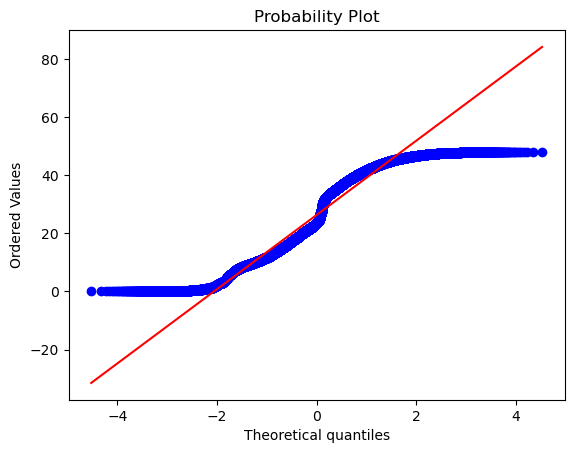

In [21]:
sns.distplot(X_train["Time"])
plt.show()
stats.probplot(X_train["Time"],dist="norm",plot=plt)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, f1_score ,recall_score

In [34]:
from sklearn.preprocessing import StandardScaler , FunctionTransformer


In [35]:
X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

We will ,first, transform Amount using log function then scale Time and Amount both.

In [39]:
tf=FunctionTransformer(func=np.log1p)

In [40]:
X_train_scaled['Amount']=tf.fit_transform(X_train['Amount'])
X_test_scaled['Amount']=tf.transform(X_test['Amount'])

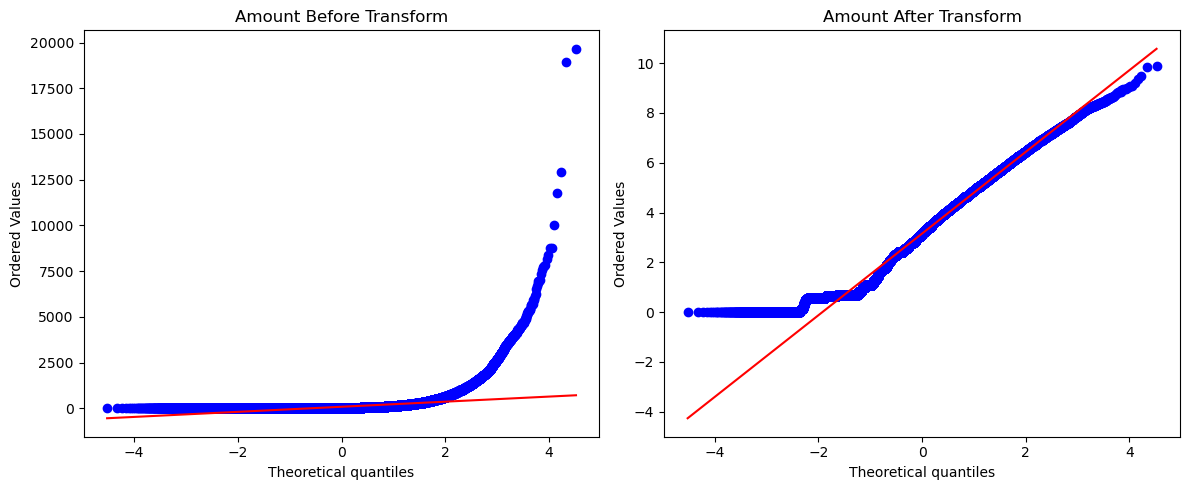

In [51]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
stats.probplot(X_train["Amount"],dist='norm',plot=plt)
plt.title('Amount Before Transform')

plt.subplot(1,2,2)
stats.probplot(X_train_scaled["Amount"],dist='norm',plot=plt)
plt.title('Amount After Transform')
plt.tight_layout()

In [53]:
X_train['Amount'].skew()

np.float64(14.393212212999096)

In [56]:
X_train_scaled['Amount'].skew()

np.float64(0.15913383255449665)

In [54]:
scaler=StandardScaler()

In [55]:
X_train_scaled[['Time','Amount']]= scaler.fit_transform(X_train_scaled[['Time','Amount']])
X_test_scaled[['Time','Amount']]=scaler.transform(X_test_scaled[['Time','Amount']])

#Model Training

In [29]:
lr1=LogisticRegression()
dt1=DecisionTreeClassifier() 


In [30]:
lr1.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul